In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


In [2]:
df = pd.read_csv("../dataset/employee_attrition.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1470
Number of columns: 35


In [5]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

In [7]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [8]:
print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [9]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Series([], dtype: int64)


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1470, 35)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [13]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [14]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Final dataset shape: (1470, 35)
Total missing values: 0
Total duplicate rows: 0


In [15]:
# Descriptive Statistics

print("Descriptive Statistics of Employee Attrition Dataset")
df.describe()

Descriptive Statistics of Employee Attrition Dataset


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Attrition
No     1233
Yes     237
Name: count, dtype: int64


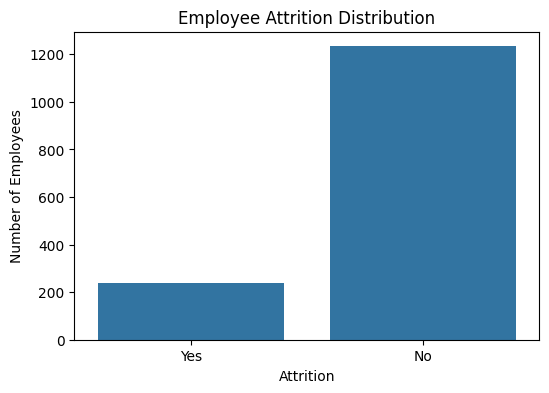

In [16]:
# Employee Attrition Distribution

print(df["Attrition"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

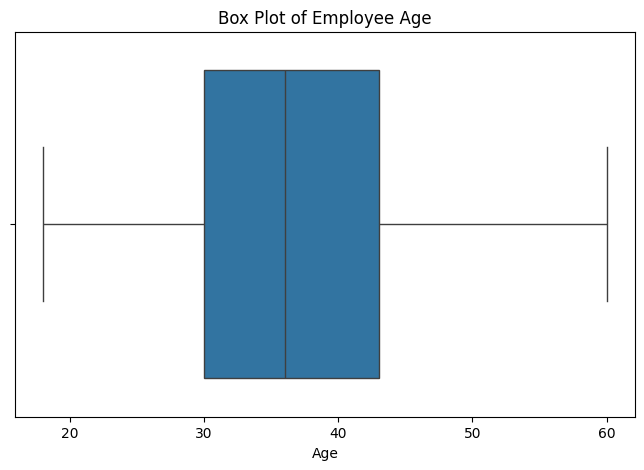

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Age"])

plt.title("Box Plot of Employee Age")
plt.xlabel("Age")

plt.savefig("../graphs/age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

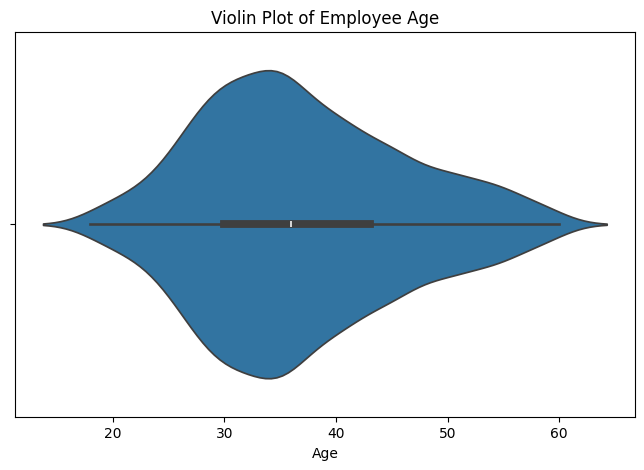

In [18]:
plt.figure(figsize=(8, 5))

sns.violinplot(x=df["Age"])

plt.title("Violin Plot of Employee Age")
plt.xlabel("Age")

plt.savefig("../graphs/age_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

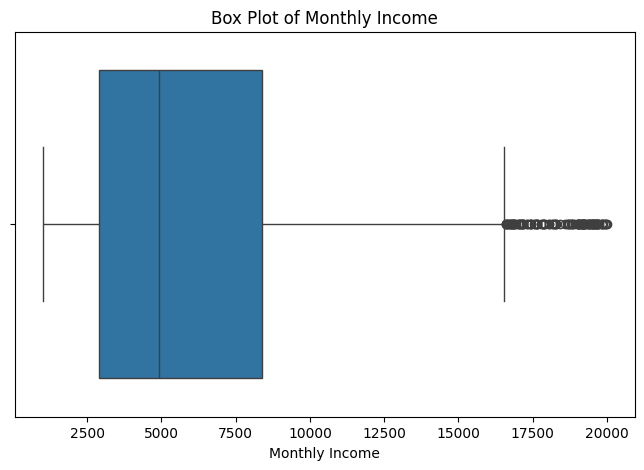

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["MonthlyIncome"])

plt.title("Box Plot of Monthly Income")
plt.xlabel("Monthly Income")

plt.savefig("../graphs/monthly_income_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

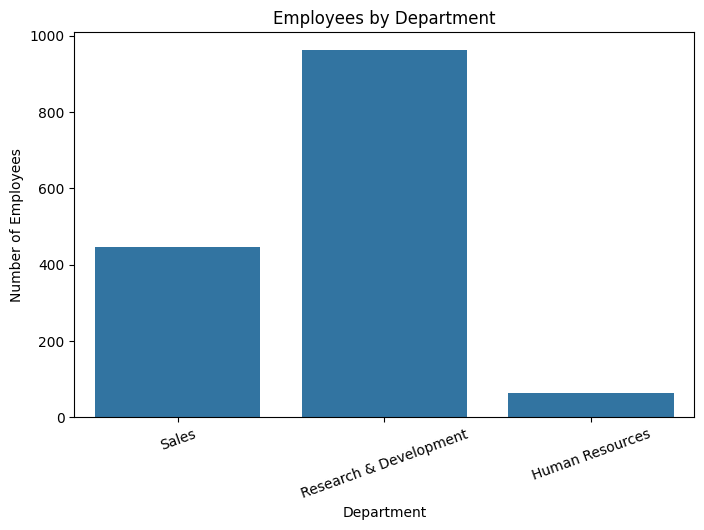

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Department")

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=20)

plt.savefig("../graphs/department_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

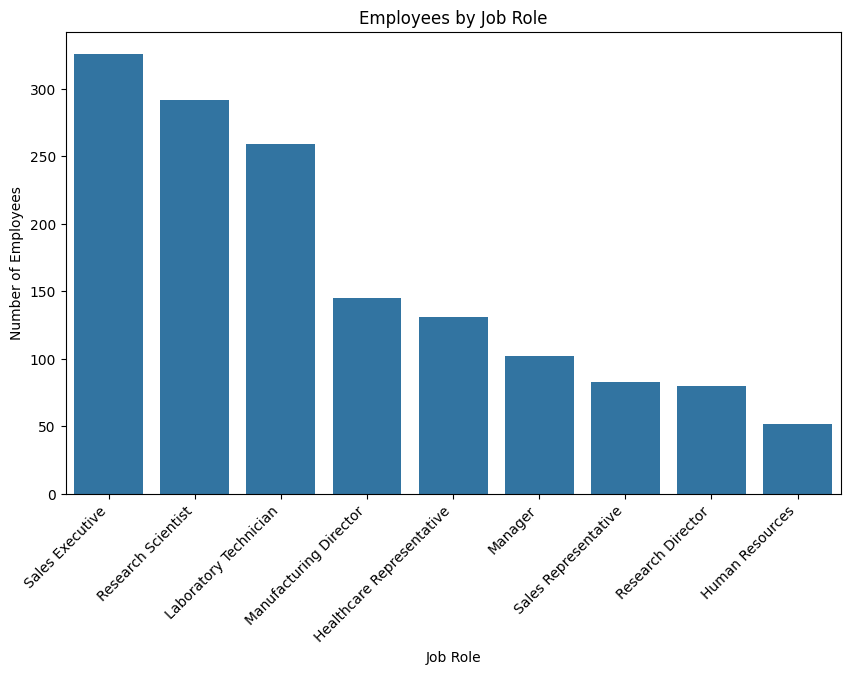

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="JobRole")

plt.title("Employees by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")

plt.savefig("../graphs/job_role_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

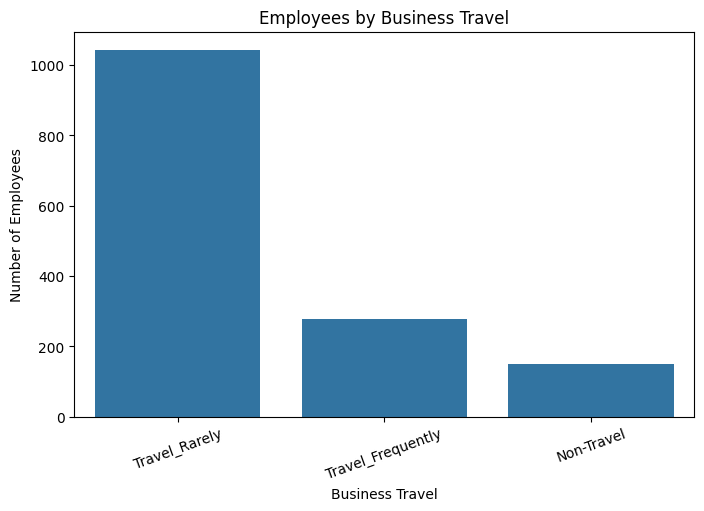

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="BusinessTravel")

plt.title("Employees by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")
plt.xticks(rotation=20)

plt.savefig("../graphs/business_travel_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

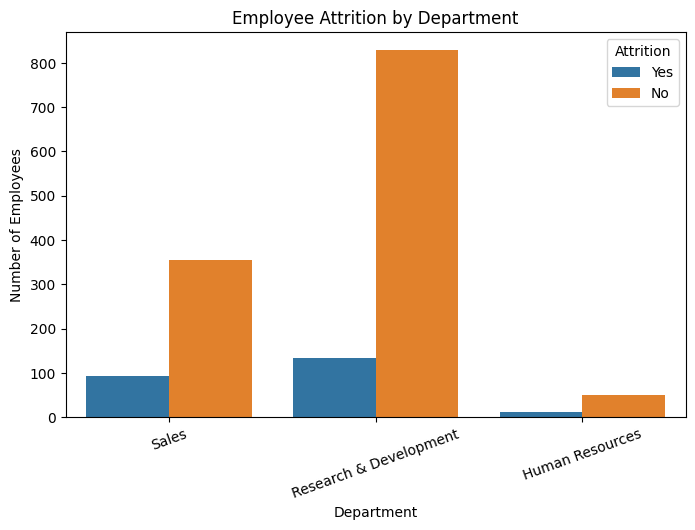

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Department", hue="Attrition")

plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=20)

plt.savefig("../graphs/attrition_by_department.png", dpi=300, bbox_inches="tight")
plt.show()

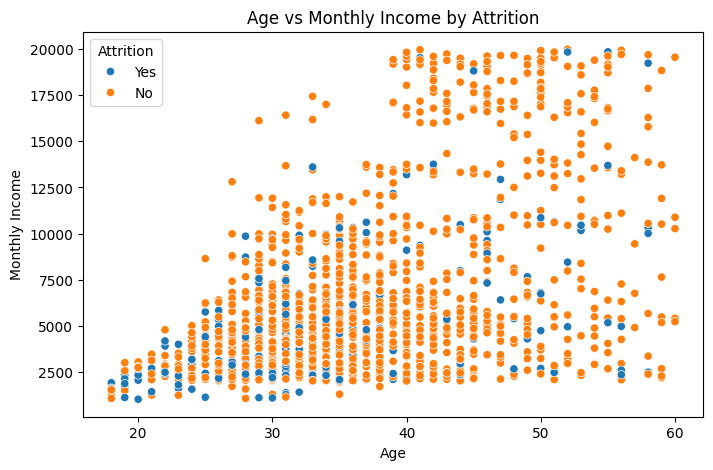

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Age", y="MonthlyIncome", hue="Attrition")

plt.title("Age vs Monthly Income by Attrition")
plt.xlabel("Age")
plt.ylabel("Monthly Income")

plt.savefig("../graphs/age_vs_income.png", dpi=300, bbox_inches="tight")
plt.show()

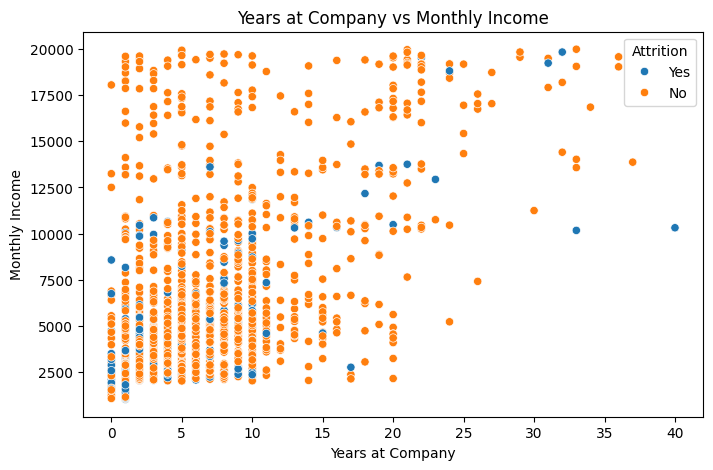

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="YearsAtCompany", y="MonthlyIncome", hue="Attrition")

plt.title("Years at Company vs Monthly Income")
plt.xlabel("Years at Company")
plt.ylabel("Monthly Income")

plt.savefig("../graphs/years_company_vs_income.png", dpi=300, bbox_inches="tight")
plt.show()

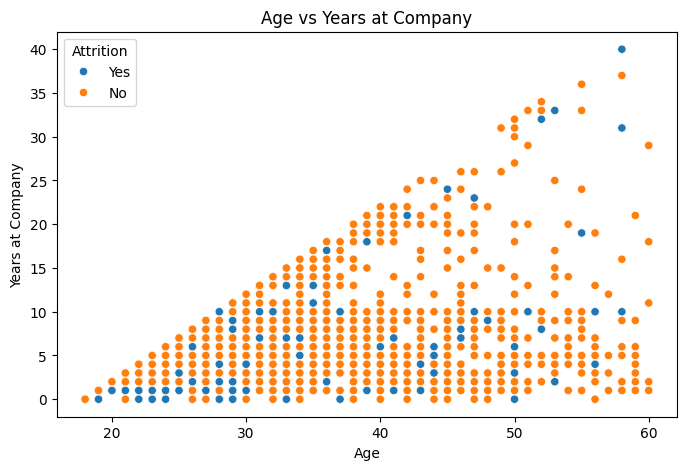

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Age", y="YearsAtCompany", hue="Attrition")

plt.title("Age vs Years at Company")
plt.xlabel("Age")
plt.ylabel("Years at Company")

plt.savefig("../graphs/age_vs_years_company.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
pair_data = df[[
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "JobSatisfaction",
    "JobInvolvement",
    "PerformanceRating"
]]

print(pair_data.head())

   Age  MonthlyIncome  YearsAtCompany  JobSatisfaction  JobInvolvement  \
0   41           5993               6                4               3   
1   49           5130              10                2               2   
2   37           2090               0                3               2   
3   33           2909               8                3               3   
4   27           3468               2                2               3   

   PerformanceRating  
0                  3  
1                  4  
2                  3  
3                  3  
4                  3  


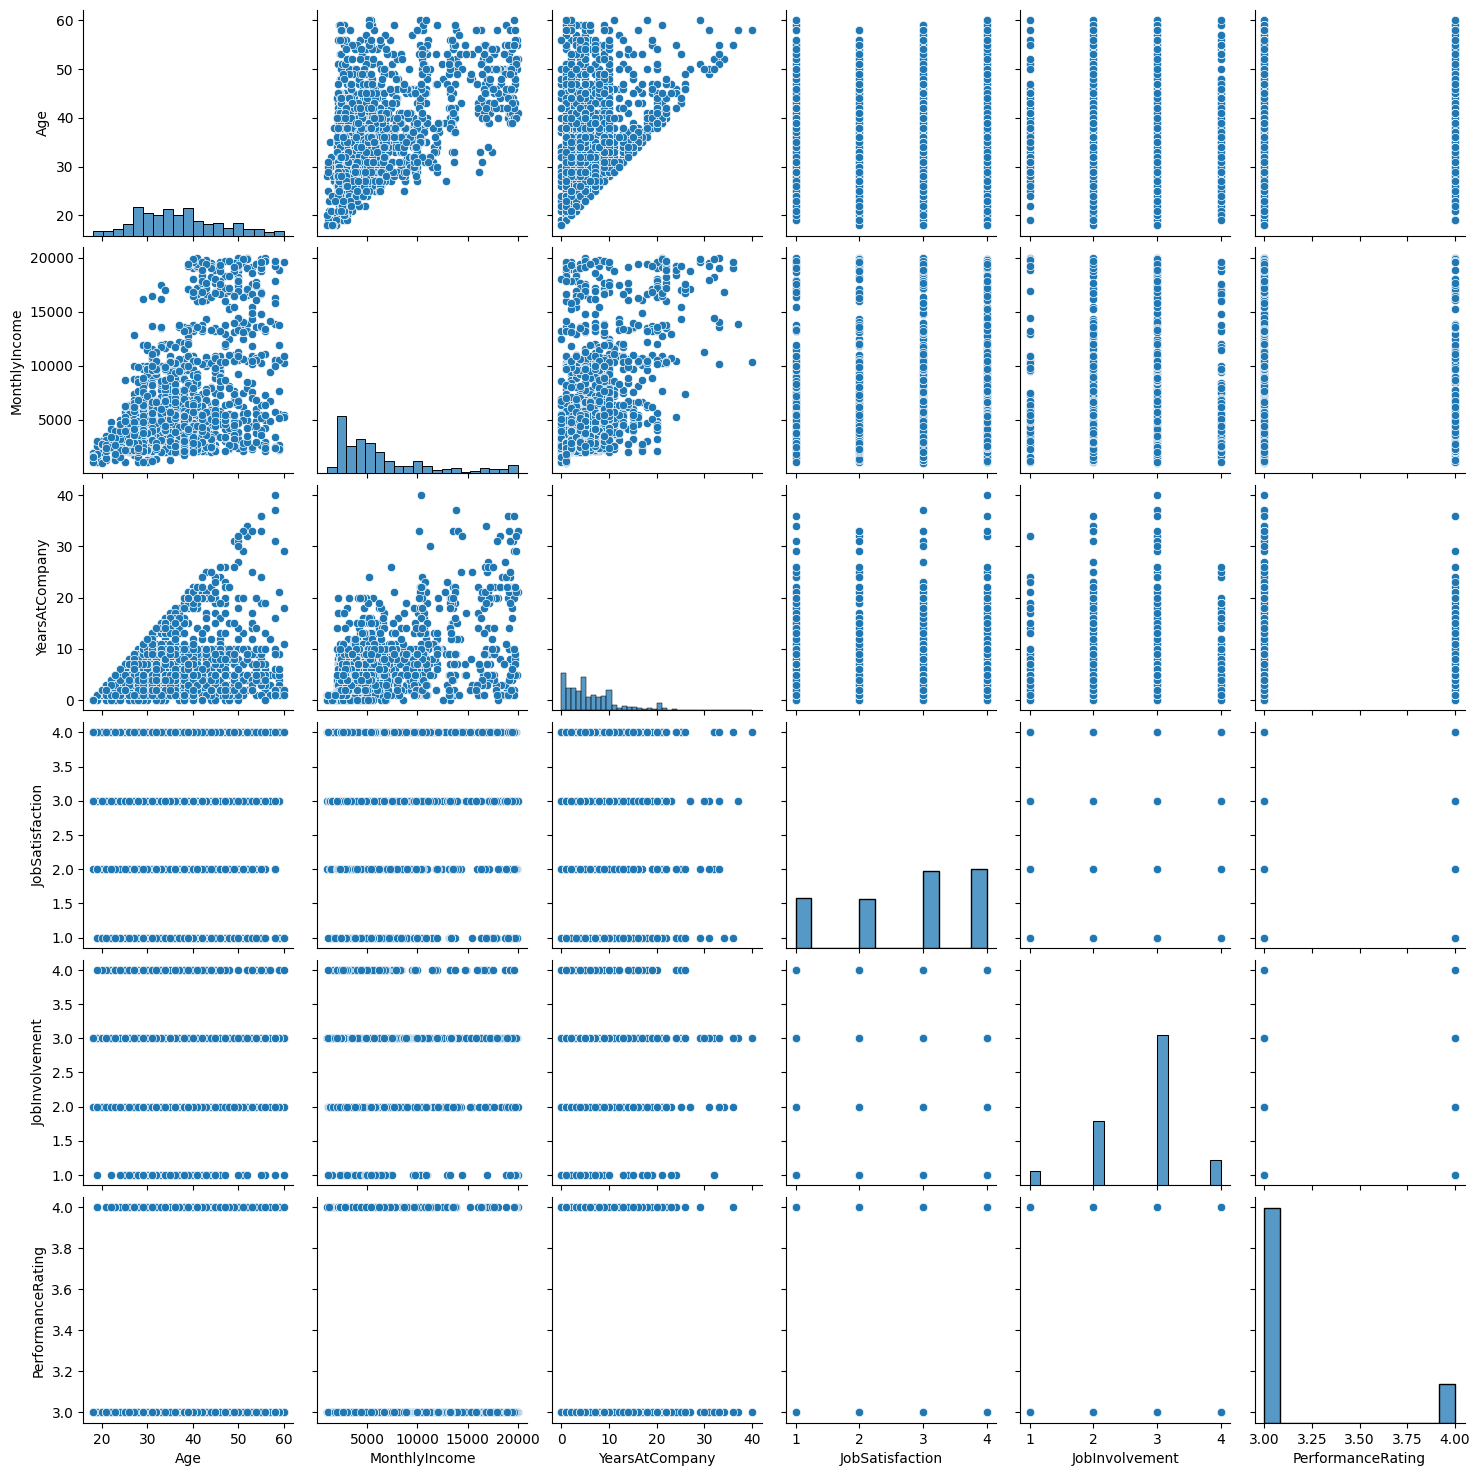

In [28]:
sns.pairplot(pair_data)

plt.savefig("../graphs/pair_plot.png", dpi=300, bbox_inches="tight")
plt.show()

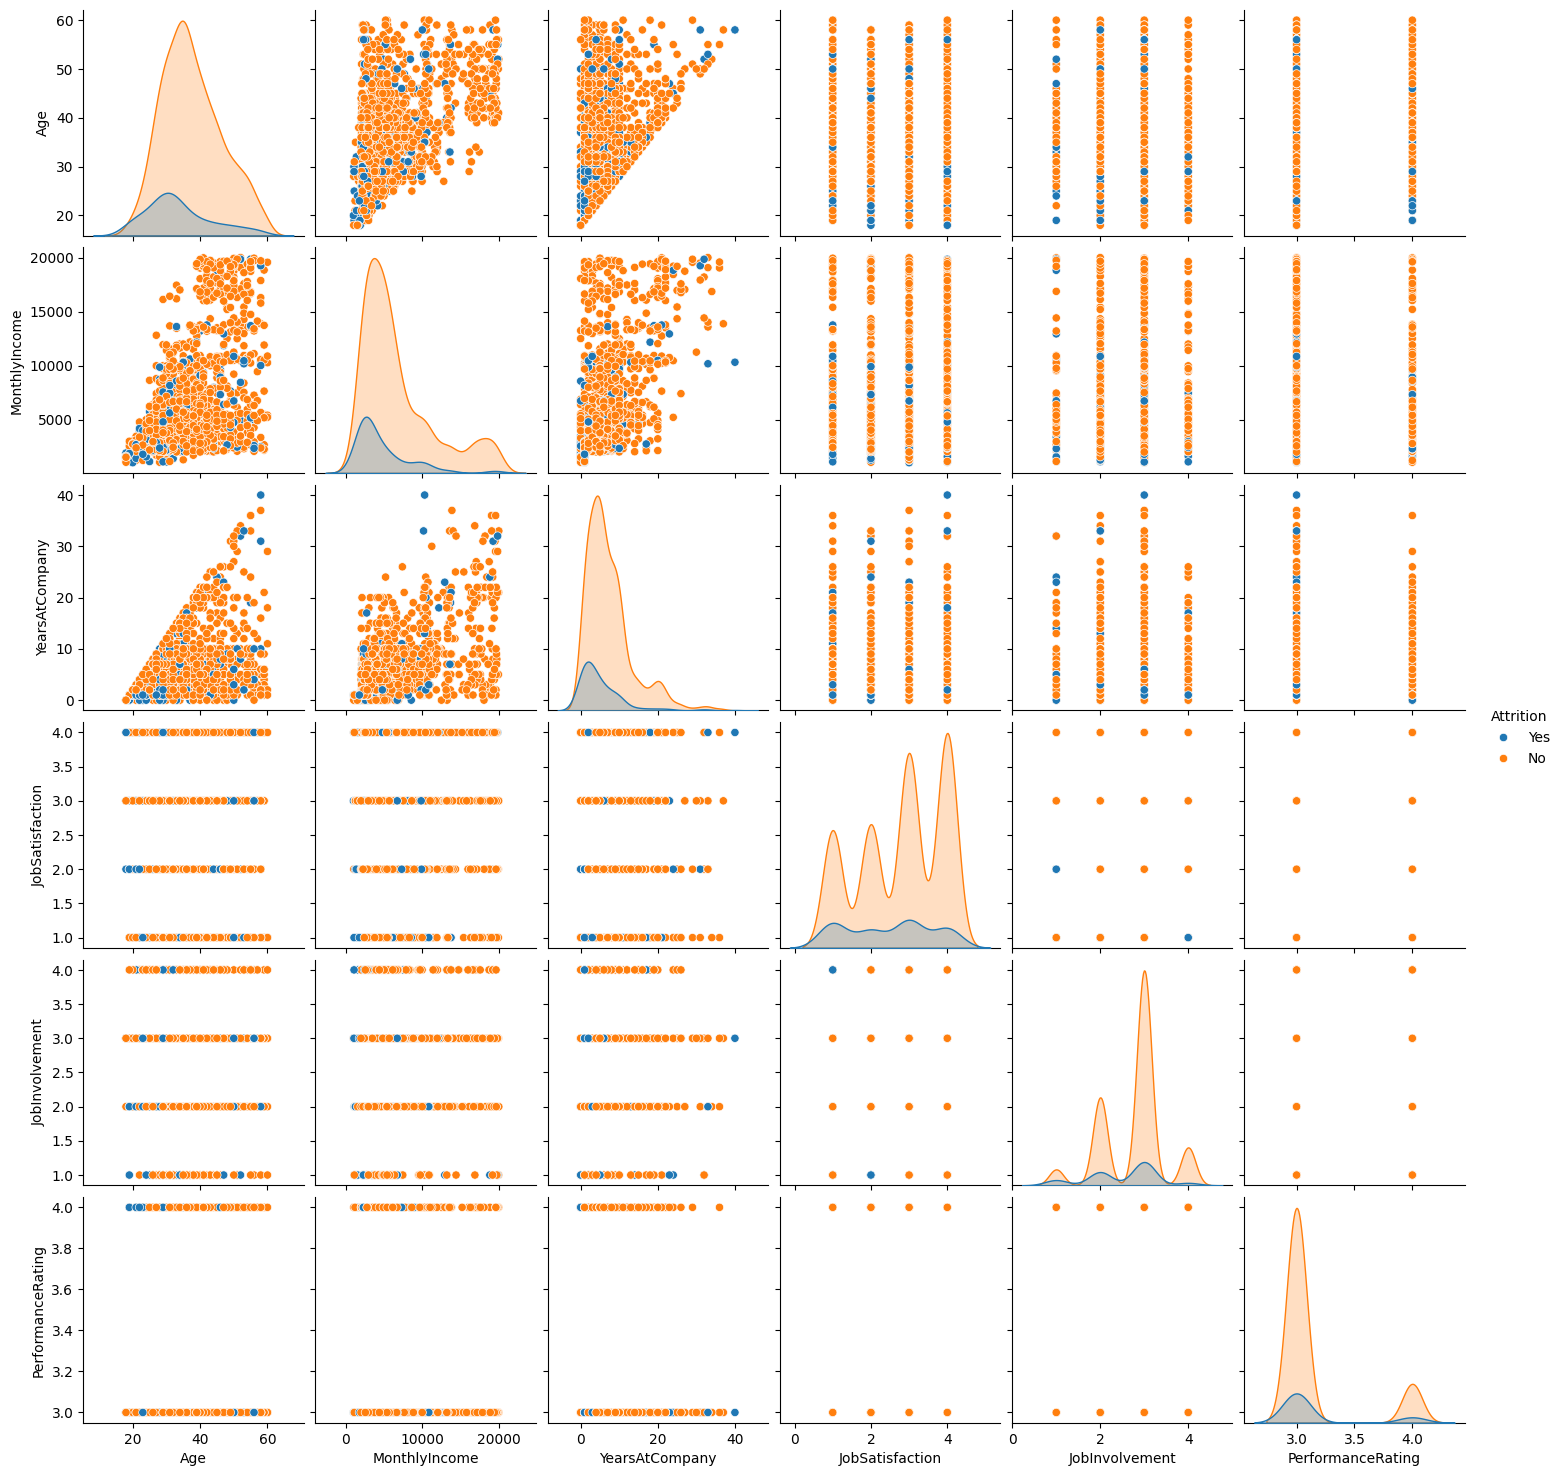

In [29]:
pair_data = df[[
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "JobSatisfaction",
    "JobInvolvement",
    "PerformanceRating",
    "Attrition"
]]

sns.pairplot(pair_data, hue="Attrition")

plt.savefig("../graphs/pair_plot_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                               Age  DailyRate  DistanceFromHome  Education  \
Age                       1.000000   0.010661         -0.001686   0.208034   
DailyRate                 0.010661   1.000000         -0.004985  -0.016806   
DistanceFromHome         -0.001686  -0.004985          1.000000   0.021042   
Education                 0.208034  -0.016806          0.021042   1.000000   
EmployeeCount                  NaN        NaN               NaN        NaN   
EmployeeNumber           -0.010145  -0.050990          0.032916   0.042070   
EnvironmentSatisfaction   0.010146   0.018355         -0.016075  -0.027128   
HourlyRate                0.024287   0.023381          0.031131   0.016775   
JobInvolvement            0.029820   0.046135          0.008783   0.042438   
JobLevel                  0.509604   0.002966          0.005303   0.101589   
JobSatisfaction          -0.004892   0.030571         -0.003669  -0.011296   
MonthlyIncome             0.497855   0.007707         -0.017014 

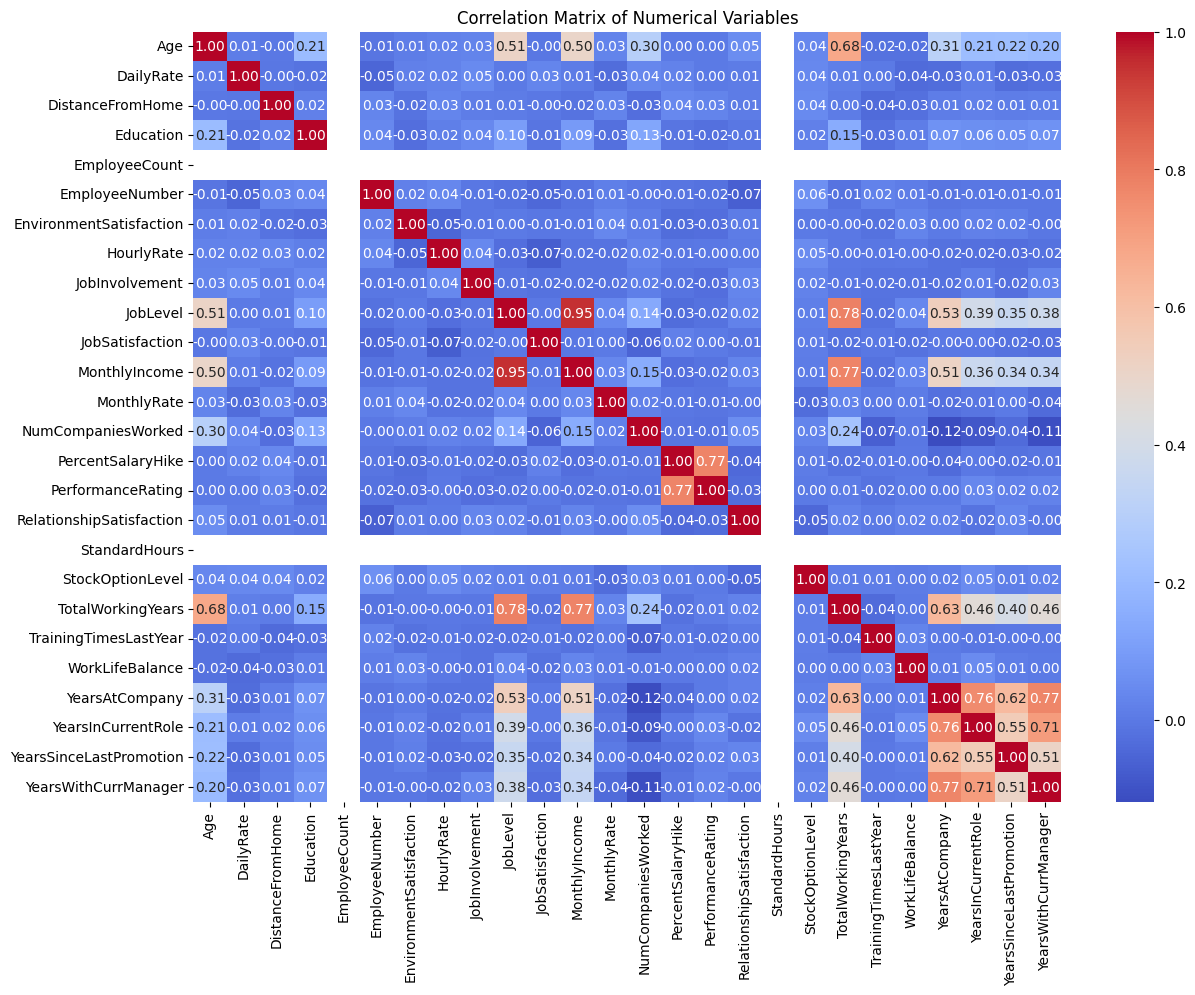

In [31]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.savefig("../graphs/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
# Outlier Analysis using IQR

columns_to_check = [
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

for column in columns_to_check:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(f"{column}: {len(outliers)} outliers")

Age: 0 outliers
MonthlyIncome: 114 outliers
YearsAtCompany: 104 outliers
YearsInCurrentRole: 21 outliers
YearsSinceLastPromotion: 107 outliers
YearsWithCurrManager: 14 outliers


In [33]:
# Display IQR limits

for column in columns_to_check:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    print("\n", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)


 Age
Q1: 30.0
Q3: 43.0
IQR: 13.0
Lower Limit: 10.5
Upper Limit: 62.5

 MonthlyIncome
Q1: 2911.0
Q3: 8379.0
IQR: 5468.0
Lower Limit: -5291.0
Upper Limit: 16581.0

 YearsAtCompany
Q1: 3.0
Q3: 9.0
IQR: 6.0
Lower Limit: -6.0
Upper Limit: 18.0

 YearsInCurrentRole
Q1: 2.0
Q3: 7.0
IQR: 5.0
Lower Limit: -5.5
Upper Limit: 14.5

 YearsSinceLastPromotion
Q1: 0.0
Q3: 3.0
IQR: 3.0
Lower Limit: -4.5
Upper Limit: 7.5

 YearsWithCurrManager
Q1: 2.0
Q3: 7.0
IQR: 5.0
Lower Limit: -5.5
Upper Limit: 14.5


In [34]:
outlier_summary = []

for column in columns_to_check:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    count = ((df[column] < lower_limit) | 
             (df[column] > upper_limit)).sum()

    outlier_summary.append([column, Q1, Q3, IQR, lower_limit, upper_limit, count])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Lower Limit",
        "Upper Limit",
        "Outlier Count"
    ]
)

outlier_table

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count
0,Age,30.0,43.0,13.0,10.5,62.5,0
1,MonthlyIncome,2911.0,8379.0,5468.0,-5291.0,16581.0,114
2,YearsAtCompany,3.0,9.0,6.0,-6.0,18.0,104
3,YearsInCurrentRole,2.0,7.0,5.0,-5.5,14.5,21
4,YearsSinceLastPromotion,0.0,3.0,3.0,-4.5,7.5,107
5,YearsWithCurrManager,2.0,7.0,5.0,-5.5,14.5,14


In [35]:
# Population

population = df["MonthlyIncome"].dropna()

print("Population size:", len(population))
print("Population mean:", population.mean())
print("Population standard deviation:", population.std())

Population size: 1470
Population mean: 6502.931292517007
Population standard deviation: 4707.956783097994


In [36]:
# Random Sample

sample = population.sample(n=100, random_state=42)

print("Sample size:", len(sample))
print("Sample mean:", sample.mean())
print("Sample standard deviation:", sample.std())

Sample size: 100
Sample mean: 6834.54
Sample standard deviation: 4517.579240069069


In [37]:
print("Population Mean:", population.mean())
print("Sample Mean:", sample.mean())

Population Mean: 6502.931292517007
Sample Mean: 6834.54


In [38]:
# Sampling Distribution of the Mean

sample_means = []

for i in range(1000):
    sample = population.sample(n=100, random_state=i)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print("Number of sample means:", len(sample_means))
print("Mean of sampling distribution:", sample_means.mean())
print("Standard deviation of sampling distribution:", sample_means.std())

Number of sample means: 1000
Mean of sampling distribution: 6519.761149999999
Standard deviation of sampling distribution: 467.8169347265846


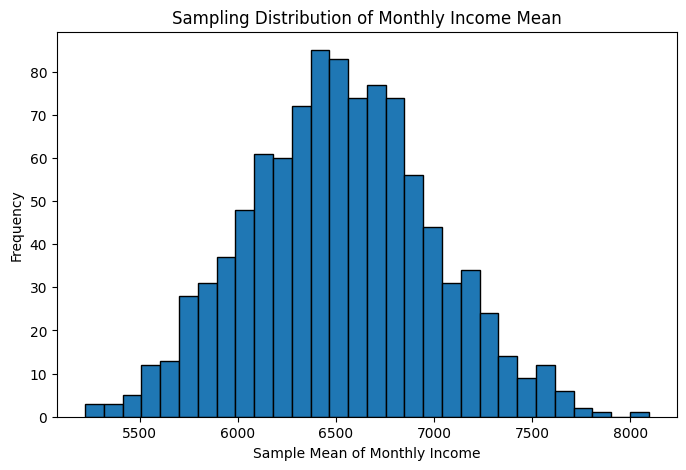

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(sample_means, bins=30, edgecolor="black")

plt.title("Sampling Distribution of Monthly Income Mean")
plt.xlabel("Sample Mean of Monthly Income")
plt.ylabel("Frequency")

plt.savefig("../graphs/sampling_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


In [40]:
# Standard Error of the Mean

standard_error = sample_means.std()

print("Standard Error:", standard_error)

Standard Error: 467.8169347265846


In [41]:
# 95% Confidence Interval using Student's t-distribution

sample = population.sample(n=100, random_state=42)

sample_mean = sample.mean()
sample_std = sample.std()
sample_size = len(sample)

standard_error = sample_std / np.sqrt(sample_size)

confidence_level = 0.95
degrees_of_freedom = sample_size - 1

t_critical = stats.t.ppf(
    (1 + confidence_level) / 2,
    degrees_of_freedom
)

margin_of_error = t_critical * standard_error

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print("Sample Mean:", sample_mean)
print("Standard Error:", standard_error)
print("Degrees of Freedom:", degrees_of_freedom)
print("t-critical value:", t_critical)
print("Margin of Error:", margin_of_error)

print("\n95% Confidence Interval:")
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Sample Mean: 6834.54
Standard Error: 451.7579240069069
Degrees of Freedom: 99
t-critical value: 1.9842169515086827
Margin of Error: 896.385730792876

95% Confidence Interval:
Lower Bound: 5938.154269207124
Upper Bound: 7730.925730792876


In [42]:
print(
    f"We are 95% confident that the population mean "
    f"Monthly Income lies between {lower_bound:.2f} and "
    f"{upper_bound:.2f}."
)

We are 95% confident that the population mean Monthly Income lies between 5938.15 and 7730.93.


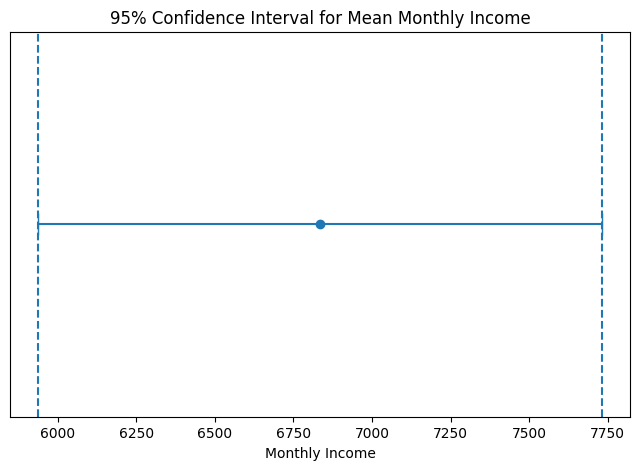

In [43]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    sample_mean,
    0,
    xerr=margin_of_error,
    fmt="o",
    capsize=8
)

plt.axvline(lower_bound, linestyle="--")
plt.axvline(upper_bound, linestyle="--")

plt.title("95% Confidence Interval for Mean Monthly Income")
plt.xlabel("Monthly Income")
plt.yticks([])

plt.savefig(
    "../graphs/confidence_interval_monthly_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# Separate Monthly Income by Attrition

income_left = df[df["Attrition"] == "Yes"]["MonthlyIncome"]
income_stayed = df[df["Attrition"] == "No"]["MonthlyIncome"]

print("Employees who left:", len(income_left))
print("Employees who stayed:", len(income_stayed))

print("\nMean Monthly Income:")
print("Left:", income_left.mean())
print("Stayed:", income_stayed.mean())

Employees who left: 237
Employees who stayed: 1233

Mean Monthly Income:
Left: 4787.0928270042195
Stayed: 6832.739659367397


In [45]:
# Independent Two-Sample t-Test

t_statistic, p_value = stats.ttest_ind(
    income_left,
    income_stayed,
    equal_var=False
)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: -7.482621586644742
p-value: 4.433588628286071e-13


In [46]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H₀).")
    print("There is a statistically significant difference in Monthly Income between the two groups.")
else:
    print("Decision: Fail to Reject the Null Hypothesis (H₀).")
    print("There is not enough statistical evidence of a significant difference in Monthly Income between the two groups.")

Decision: Reject the Null Hypothesis (H₀).
There is a statistically significant difference in Monthly Income between the two groups.


In [47]:
hypothesis_result = pd.DataFrame({
    "Test": ["Independent t-test"],
    "Variable": ["Monthly Income"],
    "Group 1": ["Attrition = Yes"],
    "Group 2": ["Attrition = No"],
    "t-statistic": [t_statistic],
    "p-value": [p_value],
    "Significance Level": [alpha]
})

hypothesis_result.to_csv(
    "../results/hypothesis_test_result.csv",
    index=False
)

hypothesis_result

,Test,Variable,Group 1,Group 2,t-statistic,p-value,Significance Level
0,Independent t-test,Monthly Income,Attrition = Yes,Attrition = No,-7.482622,4.433589e-13,0.05


In [48]:
# A/B Testing Groups

group_A = df[df["Attrition"] == "No"]["MonthlyIncome"]
group_B = df[df["Attrition"] == "Yes"]["MonthlyIncome"]

print("Group A - Stayed")
print("Number of employees:", len(group_A))
print("Mean Monthly Income:", group_A.mean())

print("\nGroup B - Left")
print("Number of employees:", len(group_B))
print("Mean Monthly Income:", group_B.mean())

Group A - Stayed
Number of employees: 1233
Mean Monthly Income: 6832.739659367397

Group B - Left
Number of employees: 237
Mean Monthly Income: 4787.0928270042195


In [49]:
# A/B Test using Welch's t-test

ab_t_stat, ab_p_value = stats.ttest_ind(
    group_A,
    group_B,
    equal_var=False
)

print("A/B Test t-statistic:", ab_t_stat)
print("A/B Test p-value:", ab_p_value)

A/B Test t-statistic: 7.482621586644742
A/B Test p-value: 4.433588628286071e-13


In [50]:
alpha = 0.05

if ab_p_value < alpha:
    print("Result: Statistically significant difference detected.")
else:
    print("Result: No statistically significant difference detected.")

Result: Statistically significant difference detected.


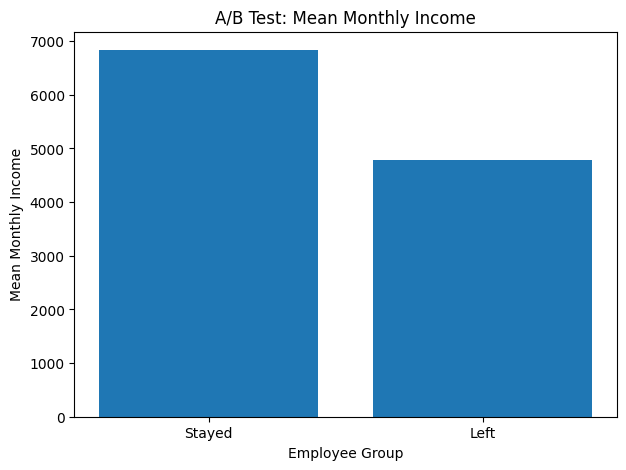

In [51]:
# Compare Mean Monthly Income

mean_values = [
    group_A.mean(),
    group_B.mean()
]

labels = ["Stayed", "Left"]

plt.figure(figsize=(7, 5))

plt.bar(labels, mean_values)

plt.title("A/B Test: Mean Monthly Income")
plt.xlabel("Employee Group")
plt.ylabel("Mean Monthly Income")

plt.savefig(
    "../graphs/ab_test_monthly_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
ab_result = pd.DataFrame({
    "Test": ["A/B Test"],
    "Metric": ["Monthly Income"],
    "Group A": ["Stayed"],
    "Group B": ["Left"],
    "Group A Mean": [group_A.mean()],
    "Group B Mean": [group_B.mean()],
    "t-statistic": [ab_t_stat],
    "p-value": [ab_p_value],
    "Significance Level": [alpha]
})

ab_result.to_csv(
    "../results/ab_test_result.csv",
    index=False
)

ab_result

,Test,Metric,Group A,Group B,Group A Mean,Group B Mean,t-statistic,p-value,Significance Level
0,A/B Test,Monthly Income,Stayed,Left,6832.739659,4787.092827,7.482622,4.433589e-13,0.05


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [55]:
# Independent variable (X) and dependent variable (y)

X = df[["Age"]]
y = df["MonthlyIncome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 1)
y shape: (1470,)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1176
Testing samples: 294


In [57]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print("Coefficient:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

Linear Regression model trained successfully!
Coefficient: 256.8684446372148
Intercept: -3063.7258717905006


In [58]:
# Predictions

y_pred = linear_model.predict(X_test)

print("First 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
[8463 4450 1555 9724 5914 2579 4230 2232 8865 2269]

First 10 predicted values:
[ 4128.59057805 10550.30169398  3101.1167995   8495.35413688
  6183.53813515  5669.80124587  5926.66969051  6954.14346906
  8495.35413688  5926.66969051]


In [59]:
# Regression Evaluation

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.21907971591706765
MAE: 3039.8460531234114
RMSE: 4131.262754386238


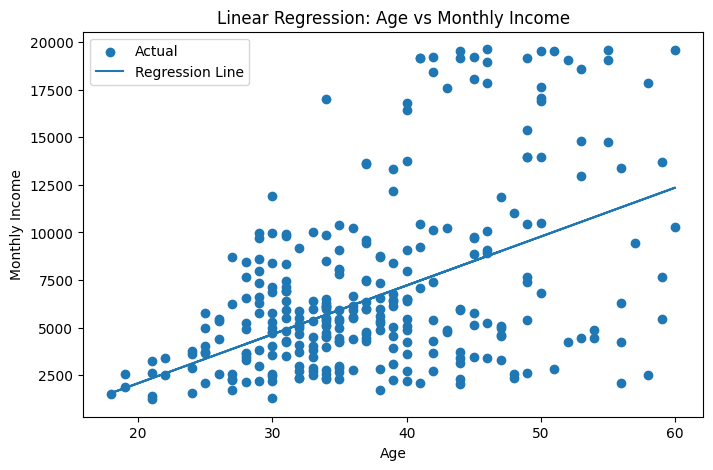

In [60]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test["Age"], y_test, label="Actual")
plt.plot(X_test["Age"], y_pred, label="Regression Line")

plt.title("Linear Regression: Age vs Monthly Income")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.legend()

plt.savefig(
    "../graphs/linear_regression_age_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
# Multiple Linear Regression Variables

features = [
    "Age",
    "JobLevel",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager"
]

X = df[features]
y = df["MonthlyIncome"]

print("Features used:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
['Age', 'JobLevel', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']

X shape: (1470, 6)
y shape: (1470,)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1176
Testing samples: 294


In [63]:
# Train Multiple Linear Regression Model

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


In [64]:
# Regression Coefficients

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": multiple_model.coef_
})

coefficients

,Feature,Coefficient
0,Age,-10.962269
1,JobLevel,3813.486073
2,TotalWorkingYears,60.729340
3,YearsAtCompany,8.364261
4,YearsInCurrentRole,-4.944354
5,YearsWithCurrManager,-49.727455


In [65]:
# Predictions

y_pred_multiple = multiple_model.predict(X_test)

print("First 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_multiple[:10])

First 10 actual values:
[8463 4450 1555 9724 5914 2579 4230 2232 8865 2269]

First 10 predicted values:
[ 6096.79899079  5763.53737285  2159.0180328  11013.28667785
  6449.78802389  2224.79711106  2206.5770341   2266.34493846
 10609.95458374  1988.70561862]


In [66]:
# Multiple Regression Evaluation

r2_multiple = r2_score(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

print("Multiple Regression Performance")
print("--------------------------------")
print("R² Score:", r2_multiple)
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)

Multiple Regression Performance
--------------------------------
R² Score: 0.8961151058812639
MAE: 1157.6889990420068
RMSE: 1506.8001909340844


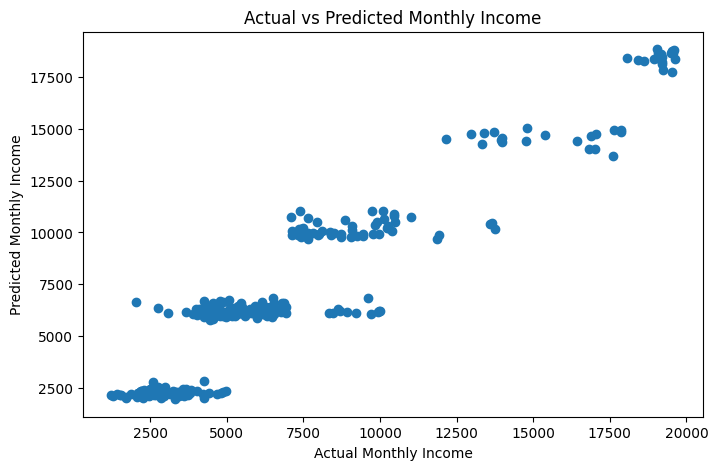

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_multiple)

plt.xlabel("Actual Monthly Income")
plt.ylabel("Predicted Monthly Income")
plt.title("Actual vs Predicted Monthly Income")

plt.savefig(
    "../graphs/multiple_regression_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
regression_results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "R2": [
        r2,
        r2_multiple
    ],
    "MAE": [
        mae,
        mae_multiple
    ],
    "RMSE": [
        rmse,
        rmse_multiple
    ]
})

regression_results.to_csv(
    "../results/regression_results.csv",
    index=False
)

regression_results

,Model,R2,MAE,RMSE
0,Simple Linear Regression,0.219080,3039.846053,4131.262754
1,Multiple Linear Regression,0.896115,1157.688999,1506.800191


In [69]:
# Calculate Residuals

residuals = y_test - y_pred_multiple

print("First 10 residuals:")
print(residuals.head(10))

First 10 residuals:
1041    2366.201009
184    -1313.537373
1222    -604.018033
67     -1289.286678
220     -535.788024
494      354.202889
430     2023.422966
240      -34.344938
218    -1744.954584
49       280.294381
Name: MonthlyIncome, dtype: float64


In [70]:
print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Residual Mean: -101.68568109814383
Residual Standard Deviation: 1505.9284554295573
Minimum Residual: -4590.3130617089055
Maximum Residual: 3910.035594630761


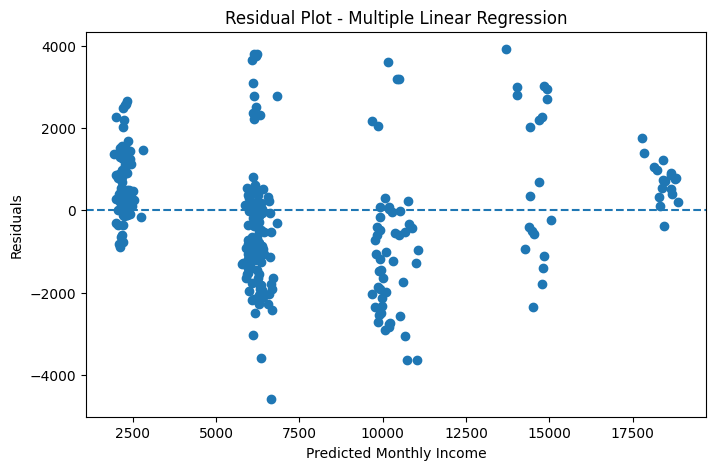

In [71]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_multiple, residuals)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Multiple Linear Regression")
plt.xlabel("Predicted Monthly Income")
plt.ylabel("Residuals")

plt.savefig(
    "../graphs/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

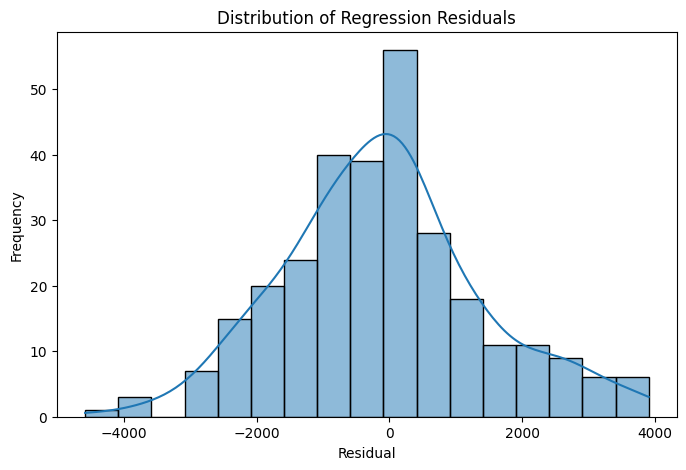

In [72]:
plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.savefig(
    "../graphs/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [74]:
# Convert Attrition into numerical values

df["Attrition_Encoded"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print(df[["Attrition", "Attrition_Encoded"]].head())

  Attrition  Attrition_Encoded
0       Yes                  1
1        No                  0
2       Yes                  1
3        No                  0
4        No                  0


In [75]:
lda_features = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "JobSatisfaction",
    "JobInvolvement",
    "PerformanceRating",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager"
]

X_lda = df[lda_features]
y_lda = df["Attrition_Encoded"]

print("Number of features:", len(lda_features))
print("X shape:", X_lda.shape)
print("y shape:", y_lda.shape)

Number of features: 10
X shape: (1470, 10)
y shape: (1470,)


In [76]:
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda,
    y_lda,
    test_size=0.20,
    random_state=42,
    stratify=y_lda
)

print("Training samples:", len(X_train_lda))
print("Testing samples:", len(X_test_lda))

Training samples: 1176
Testing samples: 294


In [77]:
lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train_lda, y_train_lda)

print("LDA model trained successfully!")

LDA model trained successfully!


In [78]:
y_pred_lda = lda_model.predict(X_test_lda)

print("First 20 predictions:")
print(y_pred_lda[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [79]:
comparison = pd.DataFrame({
    "Actual": y_test_lda.values,
    "Predicted": y_pred_lda
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [80]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [81]:
# Confusion Matrix

cm = confusion_matrix(y_test_lda, y_pred_lda)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[245   2]
 [ 45   2]]


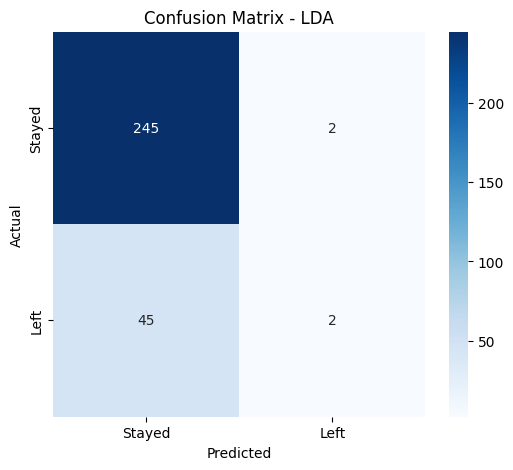

In [82]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - LDA")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../graphs/lda_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
accuracy = accuracy_score(y_test_lda, y_pred_lda)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8401360544217688
Accuracy (%): 84.01360544217688


In [84]:
precision = precision_score(y_test_lda, y_pred_lda)
recall = recall_score(y_test_lda, y_pred_lda)
f1 = f1_score(y_test_lda, y_pred_lda)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.5
Recall: 0.0425531914893617
F1-Score: 0.0784313725490196


In [85]:
print("Classification Report:")
print(
    classification_report(
        y_test_lda,
        y_pred_lda,
        target_names=["Stayed", "Left"]
    )
)

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.99      0.91       247
        Left       0.50      0.04      0.08        47

    accuracy                           0.84       294
   macro avg       0.67      0.52      0.50       294
weighted avg       0.79      0.84      0.78       294



In [86]:
lda_results = pd.DataFrame({
    "Model": ["Linear Discriminant Analysis"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1]
})

lda_results.to_csv(
    "../results/lda_results.csv",
    index=False
)

lda_results

,Model,Accuracy,Precision,Recall,F1_Score
0,Linear Discriminant Analysis,0.840136,0.5,0.042553,0.078431


In [87]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [88]:
# Create a copy of the dataset

ml_df = df.copy()

# Remove unnecessary columns
columns_to_remove = [
    "Attrition_Encoded",
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

ml_df = ml_df.drop(columns=columns_to_remove, errors="ignore")

print("Dataset shape:", ml_df.shape)

Dataset shape: (1470, 31)


In [89]:
# Target variable

y = ml_df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# Input features
X = ml_df.drop(columns=["Attrition"])

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1470, 30)
Target: (1470,)


In [90]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 23
Categorical features: 7


In [92]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", LabelEncoder())
    ]
)

In [93]:
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [94]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [95]:
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_ml))
print("Testing samples:", len(X_test_ml))

Training samples: 1176
Testing samples: 294


In [96]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train_ml, y_train_ml)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [97]:
y_pred_ml = logistic_model.predict(X_test_ml)

print("First 20 predictions:")
print(y_pred_ml[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [98]:
ml_accuracy = accuracy_score(y_test_ml, y_pred_ml)
ml_precision = precision_score(y_test_ml, y_pred_ml)
ml_recall = recall_score(y_test_ml, y_pred_ml)
ml_f1 = f1_score(y_test_ml, y_pred_ml)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", ml_accuracy)
print("Precision:", ml_precision)
print("Recall   :", ml_recall)
print("F1-Score :", ml_f1)

Logistic Regression Performance
--------------------------------
Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1-Score : 0.4383561643835616


In [99]:
print(
    classification_report(
        y_test_ml,
        y_pred_ml,
        target_names=["Stayed", "Left"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [100]:
cm_ml = confusion_matrix(y_test_ml, y_pred_ml)

print("Confusion Matrix:")
print(cm_ml)

Confusion Matrix:
[[237  10]
 [ 31  16]]


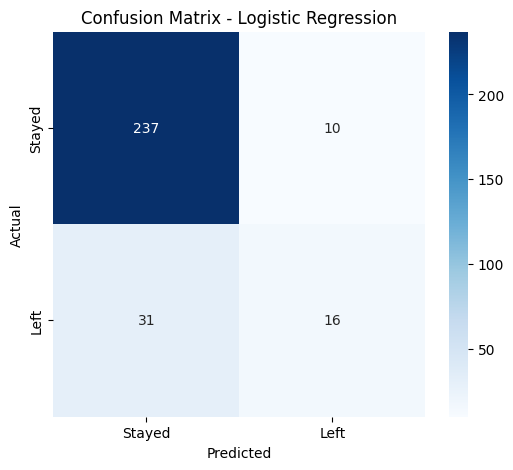

In [101]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_ml,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../graphs/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
ml_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [ml_accuracy],
    "Precision": [ml_precision],
    "Recall": [ml_recall],
    "F1_Score": [ml_f1]
})

ml_results.to_csv(
    "../results/ml_results.csv",
    index=False
)

ml_results

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356


In [103]:
from sklearn.ensemble import RandomForestClassifier

In [104]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train_ml, y_train_ml)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [105]:
y_pred_rf = random_forest_model.predict(X_test_ml)

print("First 20 predictions:")
print(y_pred_rf[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [106]:
rf_accuracy = accuracy_score(y_test_ml, y_pred_rf)
rf_precision = precision_score(y_test_ml, y_pred_rf)
rf_recall = recall_score(y_test_ml, y_pred_rf)
rf_f1 = f1_score(y_test_ml, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Random Forest Performance
-------------------------
Accuracy : 0.8503401360544217
Precision: 0.6363636363636364
Recall   : 0.14893617021276595
F1-Score : 0.2413793103448276


In [107]:
print(
    classification_report(
        y_test_ml,
        y_pred_rf,
        target_names=["Stayed", "Left"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.86      0.98      0.92       247
        Left       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294



In [108]:
cm_rf = confusion_matrix(y_test_ml, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[243   4]
 [ 40   7]]


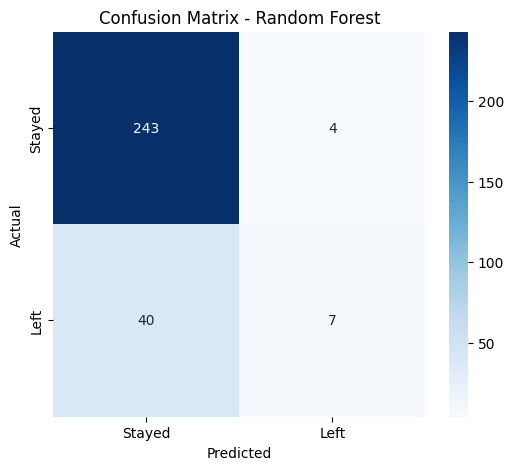

In [109]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../graphs/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        ml_accuracy,
        rf_accuracy
    ],
    "Precision": [
        ml_precision,
        rf_precision
    ],
    "Recall": [
        ml_recall,
        rf_recall
    ],
    "F1-Score": [
        ml_f1,
        rf_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356
1,Random Forest,0.850340,0.636364,0.148936,0.241379


In [111]:
model_comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [112]:
# Step 36: Final Model Performance Comparison

final_model_comparison = pd.DataFrame({
    "Model": [
        "LDA",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lda_accuracy,
        ml_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lda_precision,
        ml_precision,
        rf_precision
    ],
    "Recall": [
        lda_recall,
        ml_recall,
        rf_recall
    ],
    "F1-Score": [
        lda_f1,
        ml_f1,
        rf_f1
    ]
})

print("Final Model Performance Comparison:")
display(final_model_comparison)

NameError: name 'lda_accuracy' is not defined

In [113]:
# Step 36: Final Model Performance Comparison

# Get LDA metrics from lda_results
lda_accuracy = lda_results["Accuracy"].iloc[0]
lda_precision = lda_results["Precision"].iloc[0]
lda_recall = lda_results["Recall"].iloc[0]
lda_f1 = lda_results["F1-Score"].iloc[0]

# Create final comparison table
final_model_comparison = pd.DataFrame({
    "Model": [
        "LDA",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lda_accuracy,
        ml_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lda_precision,
        ml_precision,
        rf_precision
    ],
    "Recall": [
        lda_recall,
        ml_recall,
        rf_recall
    ],
    "F1-Score": [
        lda_f1,
        ml_f1,
        rf_f1
    ]
})

print("Final Model Performance Comparison:")
display(final_model_comparison)

KeyError: 'F1-Score'

In [114]:
# Step 36: Final Model Performance Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate LDA metrics directly
lda_accuracy = accuracy_score(y_lda_test, y_pred_lda)
lda_precision = precision_score(y_lda_test, y_pred_lda, zero_division=0)
lda_recall = recall_score(y_lda_test, y_pred_lda, zero_division=0)
lda_f1 = f1_score(y_lda_test, y_pred_lda, zero_division=0)

# Create final comparison table
final_model_comparison = pd.DataFrame({
    "Model": [
        "LDA",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lda_accuracy,
        ml_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lda_precision,
        ml_precision,
        rf_precision
    ],
    "Recall": [
        lda_recall,
        ml_recall,
        rf_recall
    ],
    "F1-Score": [
        lda_f1,
        ml_f1,
        rf_f1
    ]
})

print("Final Model Performance Comparison:")
display(final_model_comparison)

NameError: name 'y_lda_test' is not defined

In [115]:
# Step 36A: Recreate LDA data split and model

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# LDA features
lda_features = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "JobSatisfaction",
    "JobInvolvement",
    "PerformanceRating",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager"
]

X_lda_final = df[lda_features]
y_lda_final = df["Attrition"].map({"No": 0, "Yes": 1})

# Train-test split
X_lda_train_final, X_lda_test_final, y_lda_train_final, y_lda_test_final = train_test_split(
    X_lda_final,
    y_lda_final,
    test_size=0.20,
    random_state=42,
    stratify=y_lda_final
)

# Train LDA
lda_final_model = LinearDiscriminantAnalysis()
lda_final_model.fit(X_lda_train_final, y_lda_train_final)

# Prediction
y_lda_pred_final = lda_final_model.predict(X_lda_test_final)

print("LDA model recreated successfully.")
print("Test samples:", len(y_lda_test_final))

LDA model recreated successfully.
Test samples: 294


In [116]:
# Step 36B: Calculate LDA performance metrics

lda_accuracy = accuracy_score(y_lda_test_final, y_lda_pred_final)
lda_precision = precision_score(y_lda_test_final, y_lda_pred_final, zero_division=0)
lda_recall = recall_score(y_lda_test_final, y_lda_pred_final, zero_division=0)
lda_f1 = f1_score(y_lda_test_final, y_lda_pred_final, zero_division=0)

print("LDA Accuracy :", lda_accuracy)
print("LDA Precision:", lda_precision)
print("LDA Recall   :", lda_recall)
print("LDA F1-Score :", lda_f1)

LDA Accuracy : 0.8401360544217688
LDA Precision: 0.5
LDA Recall   : 0.0425531914893617
LDA F1-Score : 0.0784313725490196


In [117]:
# Step 36C: Final Model Performance Comparison

final_model_comparison = pd.DataFrame({
    "Model": [
        "LDA",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lda_accuracy,
        ml_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lda_precision,
        ml_precision,
        rf_precision
    ],
    "Recall": [
        lda_recall,
        ml_recall,
        rf_recall
    ],
    "F1-Score": [
        lda_f1,
        ml_f1,
        rf_f1
    ]
})

display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,LDA,0.840136,0.500000,0.042553,0.078431
1,Logistic Regression,0.860544,0.615385,0.340426,0.438356
2,Random Forest,0.850340,0.636364,0.148936,0.241379


In [118]:
final_model_comparison.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


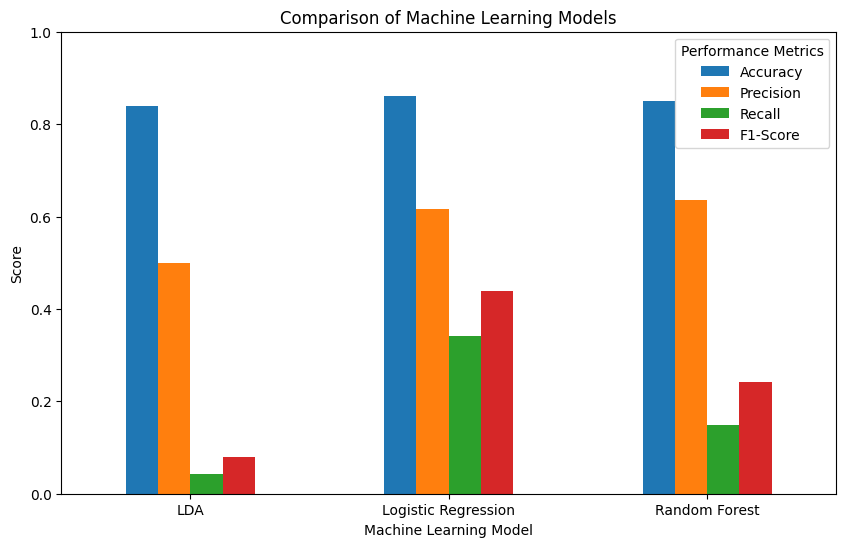

In [119]:
# Final Model Performance Comparison Graph

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

final_model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Performance Metrics")

plt.savefig(
    "../graphs/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [120]:
# Step 37: Statistical Findings

print("STATISTICAL FINDINGS")
print("=" * 50)

print("\n1. Hypothesis Testing - Monthly Income")
print("-" * 50)

print("Null Hypothesis (H0):")
print("There is no significant difference in Monthly Income between employees who stayed and employees who left.")

print("\nAlternative Hypothesis (H1):")
print("There is a significant difference in Monthly Income between employees who stayed and employees who left.")

print("\nT-statistic:", t_statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nDecision: Reject H0")
    print("Finding: The difference in Monthly Income is statistically significant.")
else:
    print("\nDecision: Fail to reject H0")
    print("Finding: The difference in Monthly Income is not statistically significant.")

STATISTICAL FINDINGS

1. Hypothesis Testing - Monthly Income
--------------------------------------------------
Null Hypothesis (H0):
There is no significant difference in Monthly Income between employees who stayed and employees who left.

Alternative Hypothesis (H1):
There is a significant difference in Monthly Income between employees who stayed and employees who left.

T-statistic: -7.482621586644742
P-value: 4.433588628286071e-13

Decision: Reject H0
Finding: The difference in Monthly Income is statistically significant.


In [121]:
print("\n2. 95% Confidence Interval for Monthly Income")
print("-" * 50)

print("Sample Mean:", sample_mean)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print(
    f"\nThe estimated population mean Monthly Income lies between "
    f"{lower_bound:.2f} and {upper_bound:.2f} with 95% confidence."
)


2. 95% Confidence Interval for Monthly Income
--------------------------------------------------
Sample Mean: 6834.54
Lower Bound: 5938.154269207124
Upper Bound: 7730.925730792876

The estimated population mean Monthly Income lies between 5938.15 and 7730.93 with 95% confidence.


In [122]:
print("\n3. Regression Analysis")
print("-" * 50)

print("Simple Linear Regression:")
print("R²:", r2_simple)
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)

print("\nMultiple Linear Regression:")
print("R²:", r2_multiple)
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)


3. Regression Analysis
--------------------------------------------------
Simple Linear Regression:


NameError: name 'r2_simple' is not defined

In [123]:
# Step 37: Regression Analysis - Corrected

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# -------------------------------------------------
# 1. Simple Linear Regression
# Predict MonthlyIncome using Age
# -------------------------------------------------

X_simple = df[["Age"]]
y_simple = df["MonthlyIncome"]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

y_pred_simple = simple_model.predict(X_test_simple)

r2_simple = r2_score(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test_simple, y_pred_simple))


# -------------------------------------------------
# 2. Multiple Linear Regression
# -------------------------------------------------

multiple_features = [
    "Age",
    "JobLevel",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager"
]

X_multiple = df[multiple_features]
y_multiple = df["MonthlyIncome"]

X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.20,
    random_state=42
)

multiple_model = LinearRegression()
multiple_model.fit(X_train_multiple, y_train_multiple)

y_pred_multiple = multiple_model.predict(X_test_multiple)

r2_multiple = r2_score(y_test_multiple, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test_multiple, y_pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y_test_multiple, y_pred_multiple))


# -------------------------------------------------
# Display Results
# -------------------------------------------------

print("REGRESSION ANALYSIS")
print("=" * 50)

print("\nSimple Linear Regression")
print("-" * 50)
print("R²   :", r2_simple)
print("MAE  :", mae_simple)
print("RMSE :", rmse_simple)

print("\nMultiple Linear Regression")
print("-" * 50)
print("R²   :", r2_multiple)
print("MAE  :", mae_multiple)
print("RMSE :", rmse_multiple)

REGRESSION ANALYSIS

Simple Linear Regression
--------------------------------------------------
R²   : 0.21907971591706765
MAE  : 3039.8460531234114
RMSE : 4131.262754386238

Multiple Linear Regression
--------------------------------------------------
R²   : 0.8961151058812639
MAE  : 1157.6889990420068
RMSE : 1506.8001909340844


In [124]:
regression_results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "R2": [
        r2_simple,
        r2_multiple
    ],
    "MAE": [
        mae_simple,
        mae_multiple
    ],
    "RMSE": [
        rmse_simple,
        rmse_multiple
    ]
})

display(regression_results)

regression_results.to_csv(
    "../results/regression_results.csv",
    index=False
)

print("Regression results saved successfully.")

,Model,R2,MAE,RMSE
0,Simple Linear Regression,0.219080,3039.846053,4131.262754
1,Multiple Linear Regression,0.896115,1157.688999,1506.800191


Regression results saved successfully.


In [125]:
print("\n3. Regression Analysis")
print("-" * 50)

print("Simple Linear Regression:")
print("R²:", r2_simple)
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)

print("\nMultiple Linear Regression:")
print("R²:", r2_multiple)
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)


3. Regression Analysis
--------------------------------------------------
Simple Linear Regression:
R²: 0.21907971591706765
MAE: 3039.8460531234114
RMSE: 4131.262754386238

Multiple Linear Regression:
R²: 0.8961151058812639
MAE: 1157.6889990420068
RMSE: 1506.8001909340844


In [126]:
# Step 38: Final Project Results Summary

final_results = pd.DataFrame({
    "Analysis": [
        "Hypothesis Testing",
        "95% Confidence Interval",
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "LDA Classification",
        "Logistic Regression",
        "Random Forest"
    ],
    "Result": [
        f"P-value = {p_value:.4f}",
        f"{lower_bound:.2f} to {upper_bound:.2f}",
        f"R² = {r2_simple:.4f}",
        f"R² = {r2_multiple:.4f}",
        f"F1-Score = {lda_f1:.4f}",
        f"F1-Score = {ml_f1:.4f}",
        f"F1-Score = {rf_f1:.4f}"
    ]
})

display(final_results)

,Analysis,Result
0,Hypothesis Testing,P-value = 0.0000
1,95% Confidence Interval,5938.15 to 7730.93
2,Simple Linear Regression,R² = 0.2191
3,Multiple Linear Regression,R² = 0.8961
4,LDA Classification,F1-Score = 0.0784
5,Logistic Regression,F1-Score = 0.4384
6,Random Forest,F1-Score = 0.2414


In [127]:
print("\n3. Regression Analysis")
print("-" * 50)

print("Simple Linear Regression:")
print("R²:", r2_simple)
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)

print("\nMultiple Linear Regression:")
print("R²:", r2_multiple)
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)


3. Regression Analysis
--------------------------------------------------
Simple Linear Regression:
R²: 0.21907971591706765
MAE: 3039.8460531234114
RMSE: 4131.262754386238

Multiple Linear Regression:
R²: 0.8961151058812639
MAE: 1157.6889990420068
RMSE: 1506.8001909340844


In [128]:
# Step 38: Final Project Results Summary

final_results = pd.DataFrame({
    "Analysis": [
        "Hypothesis Testing",
        "95% Confidence Interval",
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "LDA Classification",
        "Logistic Regression",
        "Random Forest"
    ],
    "Result": [
        f"P-value = {p_value:.4f}",
        f"{lower_bound:.2f} to {upper_bound:.2f}",
        f"R² = {r2_simple:.4f}",
        f"R² = {r2_multiple:.4f}",
        f"F1-Score = {lda_f1:.4f}",
        f"F1-Score = {ml_f1:.4f}",
        f"F1-Score = {rf_f1:.4f}"
    ]
})

display(final_results)

,Analysis,Result
0,Hypothesis Testing,P-value = 0.0000
1,95% Confidence Interval,5938.15 to 7730.93
2,Simple Linear Regression,R² = 0.2191
3,Multiple Linear Regression,R² = 0.8961
4,LDA Classification,F1-Score = 0.0784
5,Logistic Regression,F1-Score = 0.4384
6,Random Forest,F1-Score = 0.2414


In [129]:
# Save final results

final_results.to_csv(
    "../results/final_project_results.csv",
    index=False
)

print("Final project results saved successfully.")

Final project results saved successfully.


<Figure size 1000x600 with 0 Axes>

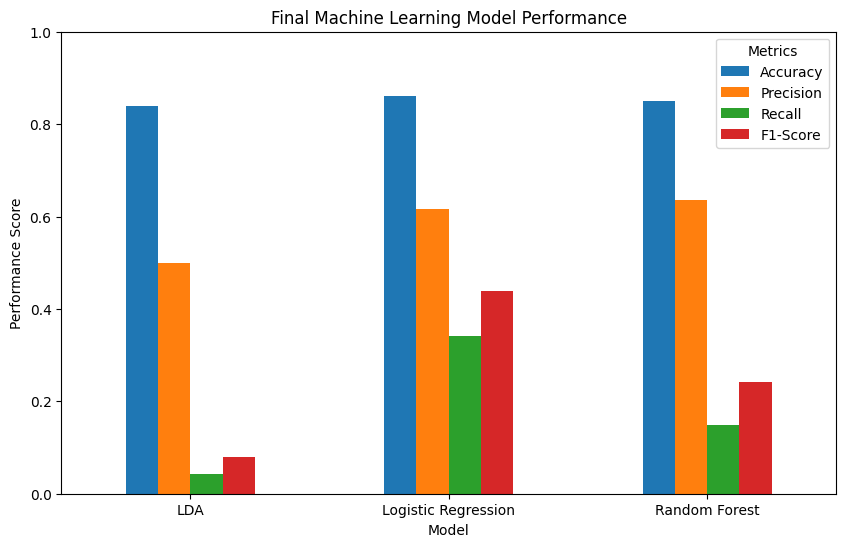

In [130]:
# Step 38: Final Model Performance Graph

plt.figure(figsize=(10, 6))

final_model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Final Machine Learning Model Performance")
plt.xlabel("Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.savefig(
    "../graphs/final_ml_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
# Step 39: Final Project Conclusion

print("=" * 70)
print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print("\n1. DATA CLEANING")
print("-" * 70)
print("The employee attrition dataset was checked for missing values and duplicate records.")
print("The dataset was cleaned and prepared for statistical analysis and machine learning.")

print("\n2. EXPLORATORY DATA ANALYSIS")
print("-" * 70)
print("EDA was performed using descriptive statistics and different visualizations.")
print("Histograms, boxplots, violin plots, bar charts, scatter plots, pair plots,")
print("and a correlation heatmap were used to understand the dataset.")

print("\n3. SAMPLING AND CONFIDENCE INTERVAL")
print("-" * 70)
print(f"The estimated mean Monthly Income from the sample was {sample_mean:.2f}.")
print(
    f"The 95% confidence interval for the population mean was "
    f"{lower_bound:.2f} to {upper_bound:.2f}."
)

print("\n4. HYPOTHESIS TESTING")
print("-" * 70)
print(f"The Welch independent samples t-test produced a p-value of {p_value:.4f}.")

if p_value < 0.05:
    print("At the 5% significance level, the null hypothesis was rejected.")
    print("The analysis indicates a statistically significant difference in")
    print("Monthly Income between the two attrition groups.")
else:
    print("At the 5% significance level, the null hypothesis was not rejected.")
    print("The analysis did not provide sufficient evidence of a statistically")
    print("significant difference in Monthly Income between the two attrition groups.")

print("\n5. REGRESSION ANALYSIS")
print("-" * 70)
print(f"Simple Linear Regression R²   : {r2_simple:.4f}")
print(f"Simple Linear Regression MAE  : {mae_simple:.2f}")
print(f"Simple Linear Regression RMSE : {rmse_simple:.2f}")

print(f"\nMultiple Linear Regression R²   : {r2_multiple:.4f}")
print(f"Multiple Linear Regression MAE  : {mae_multiple:.2f}")
print(f"Multiple Linear Regression RMSE : {rmse_multiple:.2f}")

print("\n6. CLASSIFICATION ANALYSIS")
print("-" * 70)

print(f"LDA - Accuracy  : {lda_accuracy:.4f}")
print(f"LDA - Precision : {lda_precision:.4f}")
print(f"LDA - Recall    : {lda_recall:.4f}")
print(f"LDA - F1-Score  : {lda_f1:.4f}")

print(f"\nLogistic Regression - Accuracy  : {ml_accuracy:.4f}")
print(f"Logistic Regression - Precision : {ml_precision:.4f}")
print(f"Logistic Regression - Recall    : {ml_recall:.4f}")
print(f"Logistic Regression - F1-Score  : {ml_f1:.4f}")

print(f"\nRandom Forest - Accuracy  : {rf_accuracy:.4f}")
print(f"Random Forest - Precision : {rf_precision:.4f}")
print(f"Random Forest - Recall    : {rf_recall:.4f}")
print(f"Random Forest - F1-Score  : {rf_f1:.4f}")

print("\n7. OVERALL CONCLUSION")
print("-" * 70)
print(
    "The project demonstrates how statistical methods and machine learning "
    "can be combined to analyze employee attrition."
)
print(
    "Data cleaning and EDA helped identify important patterns in employee "
    "characteristics and workplace factors."
)
print(
    "Sampling distributions, confidence intervals, and hypothesis testing "
    "provided statistical evidence for the analysis."
)
print(
    "Regression techniques were used to study relationships involving "
    "Monthly Income, while discriminant analysis and classification models "
    "were used for employee attrition prediction."
)
print(
    "The results demonstrate the application of Statistical Machine Learning "
    "techniques to a real-world-style workforce analytics problem."
)

print("=" * 70)
print("PROJECT ANALYSIS COMPLETED")
print("=" * 70)

FINAL PROJECT CONCLUSION

1. DATA CLEANING
----------------------------------------------------------------------
The employee attrition dataset was checked for missing values and duplicate records.
The dataset was cleaned and prepared for statistical analysis and machine learning.

2. EXPLORATORY DATA ANALYSIS
----------------------------------------------------------------------
EDA was performed using descriptive statistics and different visualizations.
Histograms, boxplots, violin plots, bar charts, scatter plots, pair plots,
and a correlation heatmap were used to understand the dataset.

3. SAMPLING AND CONFIDENCE INTERVAL
----------------------------------------------------------------------
The estimated mean Monthly Income from the sample was 6834.54.
The 95% confidence interval for the population mean was 5938.15 to 7730.93.

4. HYPOTHESIS TESTING
----------------------------------------------------------------------
The Welch independent samples t-test produced a p-value of 0

In [ ]:
# Save conclusion for project report

conclusion_text = f"""
FINAL PROJECT CONCLUSION

The project demonstrates the application of statistical machine learning
techniques for employee attrition analysis and prediction.

Data cleaning and exploratory data analysis were performed to understand
the structure, distribution, relationships, and patterns in the dataset.

Sampling distribution and a 95% confidence interval were calculated for
Monthly Income. The confidence interval was {lower_bound:.2f} to {upper_bound:.2f}.

A Welch independent samples t-test was performed to examine the difference
in Monthly Income between employees who stayed and employees who left.
The obtained p-value was {p_value:.4f}.

Simple and multiple linear regression models were developed to analyze
Monthly Income. The R² values were {r2_simple:.4f} and {r2_multiple:.4f},
respectively.

LDA, Logistic Regression, and Random Forest were applied for employee
attrition classification. Accuracy, Precision, Recall, and F1-Score were
used to evaluate the classification models.

Overall, the project demonstrates how statistical analysis and machine
learning can be integrated to study employee attrition and workforce
patterns using Statistical Machine Learning techniques.
"""

with open("../results/final_conclusion.txt", "w", encoding="utf-8") as file:
    file.write(conclusion_text)

print("Final conclusion saved successfully.")